In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

wine=load_wine()
X=wine.data
feature_names=wine.feature_names

df=pd.DataFrame(X,columns=feature_names)
print(f"Shape of DataSets : {df.shape}")
print(f"First 5 Rows of Datasets")
df.head()

Shape of DataSets : (178, 13)
First 5 Rows of Datasets


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Shape of Selected Features : (178, 2)


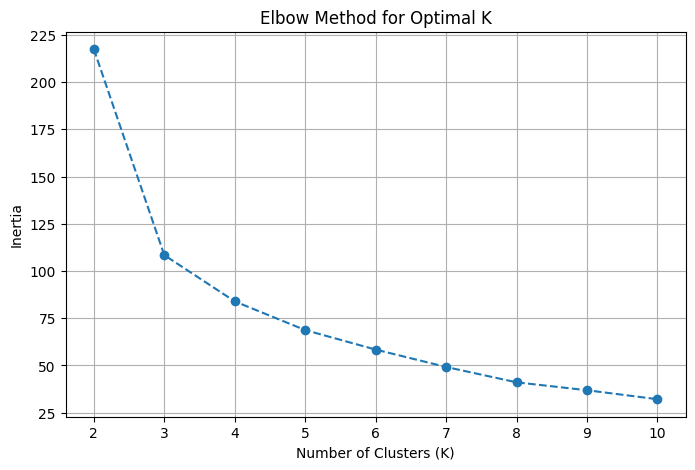

In [31]:
selected_feature=['alcohol','malic_acid']
X_Selected=df[selected_feature].values

print(f"Shape of Selected Features : {X_Selected.shape}")

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_Selected)

inertia_values=[]
K_range=range(2,11)

for k in K_range:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(K_range,inertia_values,marker='o',linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid()
plt.show()

Cluster Scaled Values
[[-0.98858319 -0.5829103 ]
 [ 0.09906621  1.41480748]
 [ 0.87009843 -0.493973  ]]


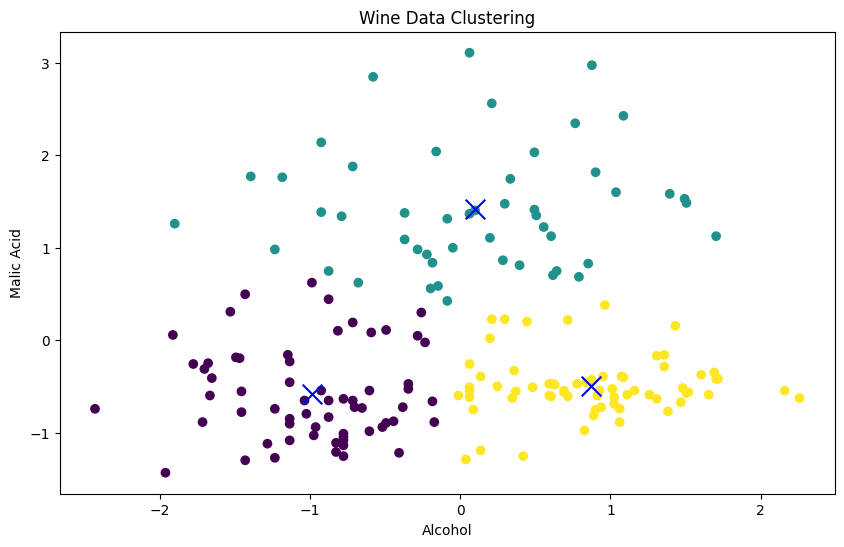

In [32]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10

)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

print("Cluster Scaled Values")
print(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='x',
    s=200,
    c='blue'
)

plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('Wine Data Clustering')
plt.show()

In [33]:
print(f"Silhoute Score")
print(silhouette_score(X_scaled,clusters))
# """
# if Value Near to ! means good Clustring
# if value near to 0 means overfitting
# if value near to 1 means poor Clustring
# """

print(f"Number of sample in each cluster")
print(df['cluster'].value_counts())

Silhoute Score
0.484095893654603
Number of sample in each cluster
cluster
2    66
0    63
1    49
Name: count, dtype: int64
